In [5]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
from sklearn.datasets import fetch_california_housing 
housing =fetch_california_housing() 

In [7]:
print(housing.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])


In [8]:
df= pd.DataFrame(
    housing.data,
    columns= housing.feature_names
)

In [9]:
df['Price']= housing.target

In [10]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [11]:
df.shape

(20640, 9)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [13]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [14]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

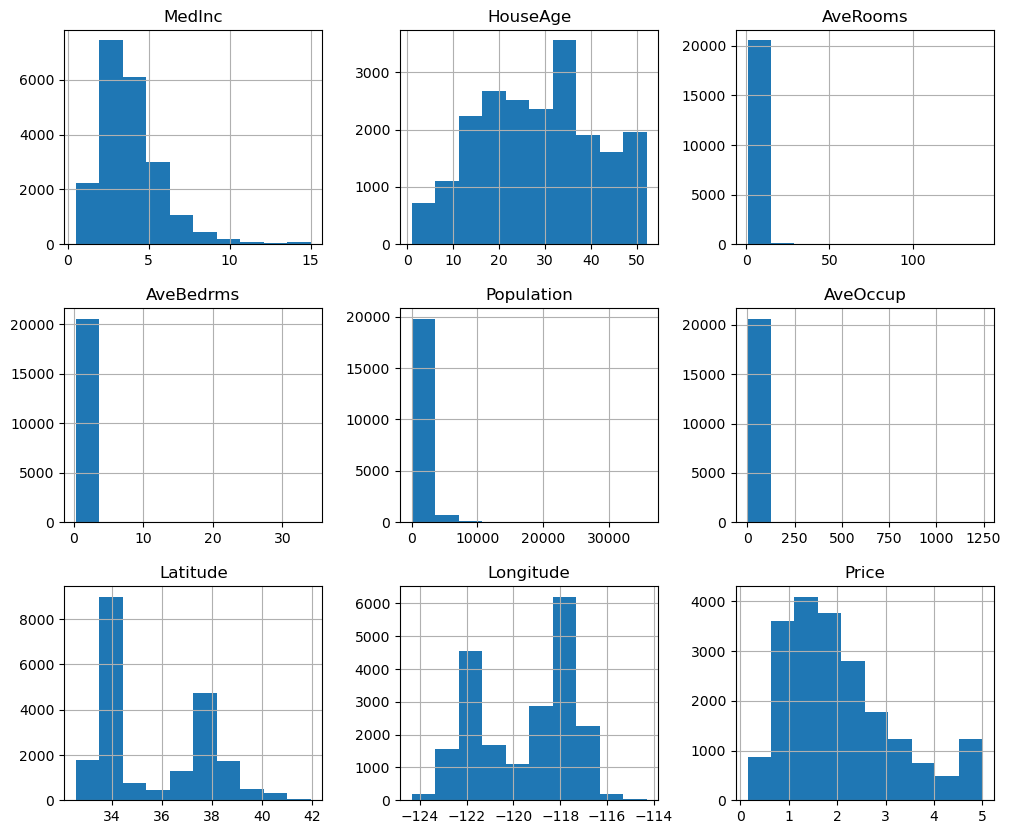

In [15]:
df.hist(figsize=(12,10))
plt.show()

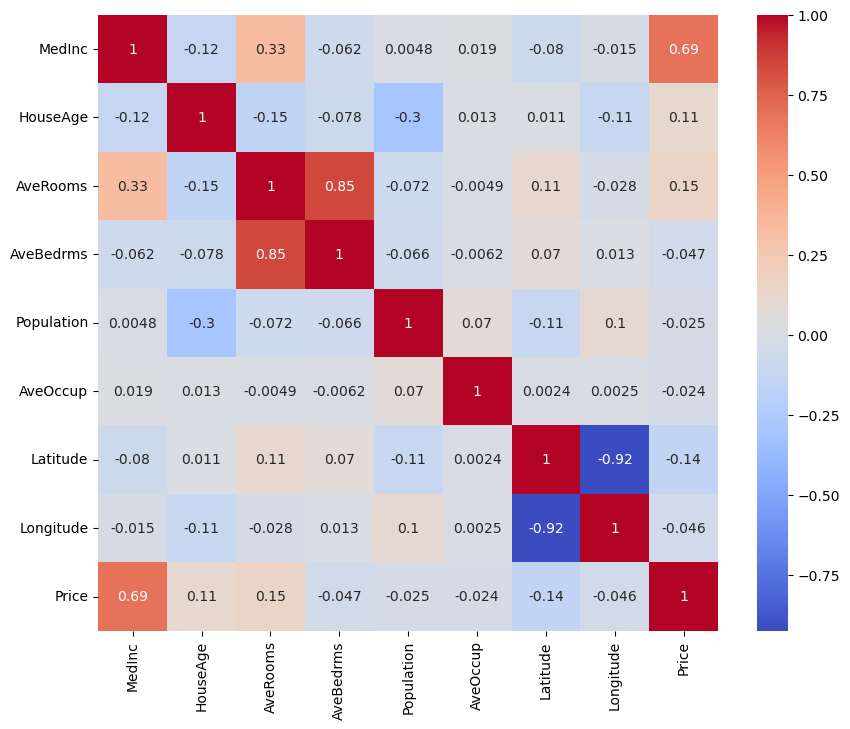

In [16]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

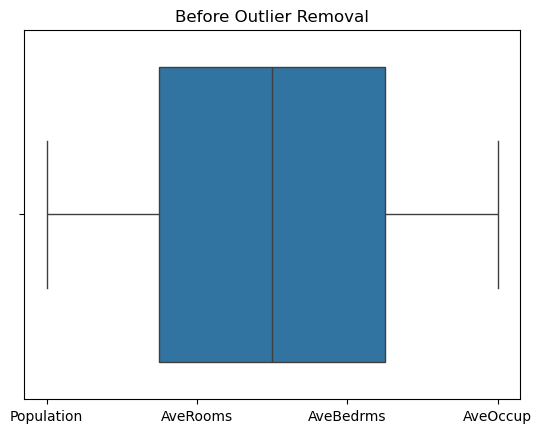

In [50]:
sns.boxplot(x=["Population", "AveRooms", "AveBedrms", "AveOccup"])
plt.title("Before Outlier Removal")
plt.show()

In [18]:
skewed_columns=["Population", "AveRooms", "AveBedrms", "AveOccup"]

for col in skewed_columns:
    Q1= df[col].quantile(0.25)
    Q3= df[col].quantile(0.75)
    IQR= Q3-Q1

lower= Q1-1.5*IQR
upper=Q3+1.5*IQR

df= df[(df[col]>=lower)&
    (df[col]<=upper)]

df= df[df["Price"]<4.9]

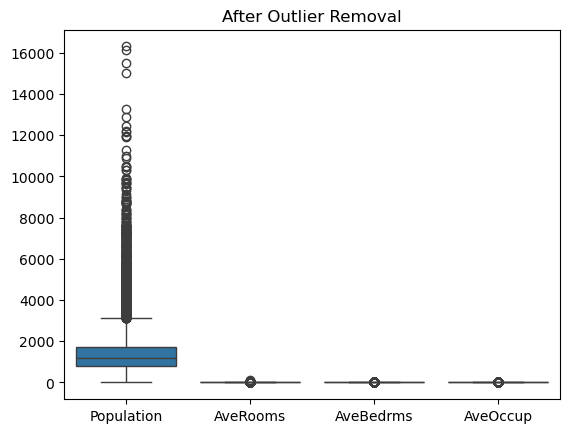

In [52]:
sns.boxplot(df[skewed_columns])
plt.title("After Outlier Removal")
plt.show()

In [23]:
x= df.drop("Price", axis=1)
y= df["Price"]

In [28]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test= train_test_split(
    x,
    y,
    test_size= 0.2,  
    random_state= 42
)

In [31]:
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler()
x_train= scaler.fit_transform(x_train)
x_test= scaler.transform(x_test)
y= df["Price"]

In [32]:
from sklearn.linear_model import LinearRegression
model= LinearRegression()

In [33]:
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [34]:
y_pred= model.predict(x_test)

In [35]:
comparision= pd.DataFrame({
    "Actual":y_test,
    "Predicted":y_pred
})

comparision.head()

,Actual,Predicted
19663,0.861,1.091710
10839,4.147,4.119847
18952,0.990,1.602877
2953,0.633,1.260952
6618,2.306,1.951373


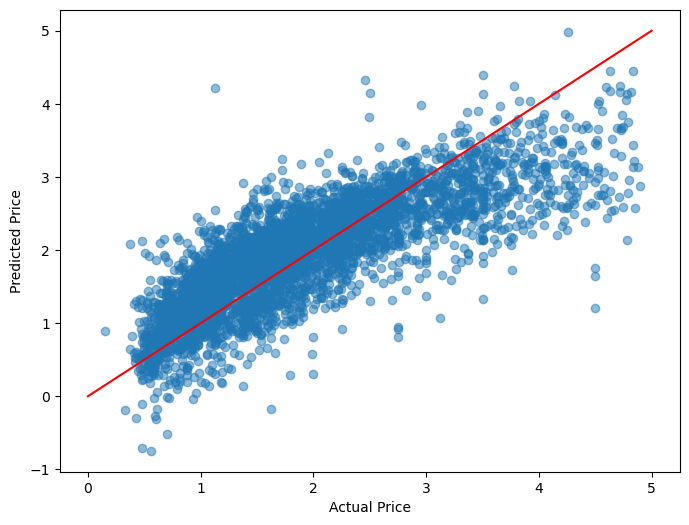

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha= 0.5
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.plot([0,5],[0,5], color='red')
plt.show()

In [37]:
from sklearn.metrics import(
mean_absolute_error,
mean_squared_error,
r2_score
)

In [38]:
mae= mean_absolute_error(
    y_test,
    y_pred
)
print(mae)

0.4409000050634715


In [39]:
mse= mean_squared_error(
    y_test,
    y_pred
)
print(mse)

0.3331791156644258


In [40]:
rmse= np.sqrt(mse)
print(rmse)

0.5772166973194953


In [41]:
r2= r2_score(
    y_test,
    y_pred
)
print(r2)

0.6454721120267023


In [42]:
residuals= y_test-y_pred

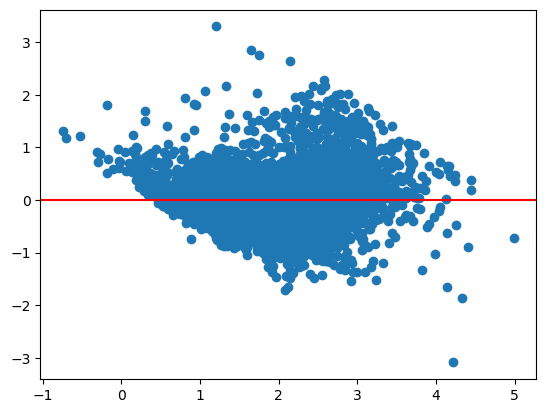

In [43]:
plt.scatter(y_pred,residuals)
plt.axhline(y=0,color='red')
plt.show()

In [45]:
from sklearn.linear_model import Ridge
ridge= Ridge(alpha=1)
ridge.fit(x_train,y_train)
ridge_pred=ridge.predict(x_test)
print(r2_score(y_test,ridge_pred))


0.645461951356017


In [46]:
from sklearn.linear_model import Lasso
lasso= Lasso(alpha=0.01)
lasso.fit(x_train,y_train)
lasso_pred=lasso.predict(x_test)
print(r2_score(y_test,lasso_pred))

0.6353094226434776


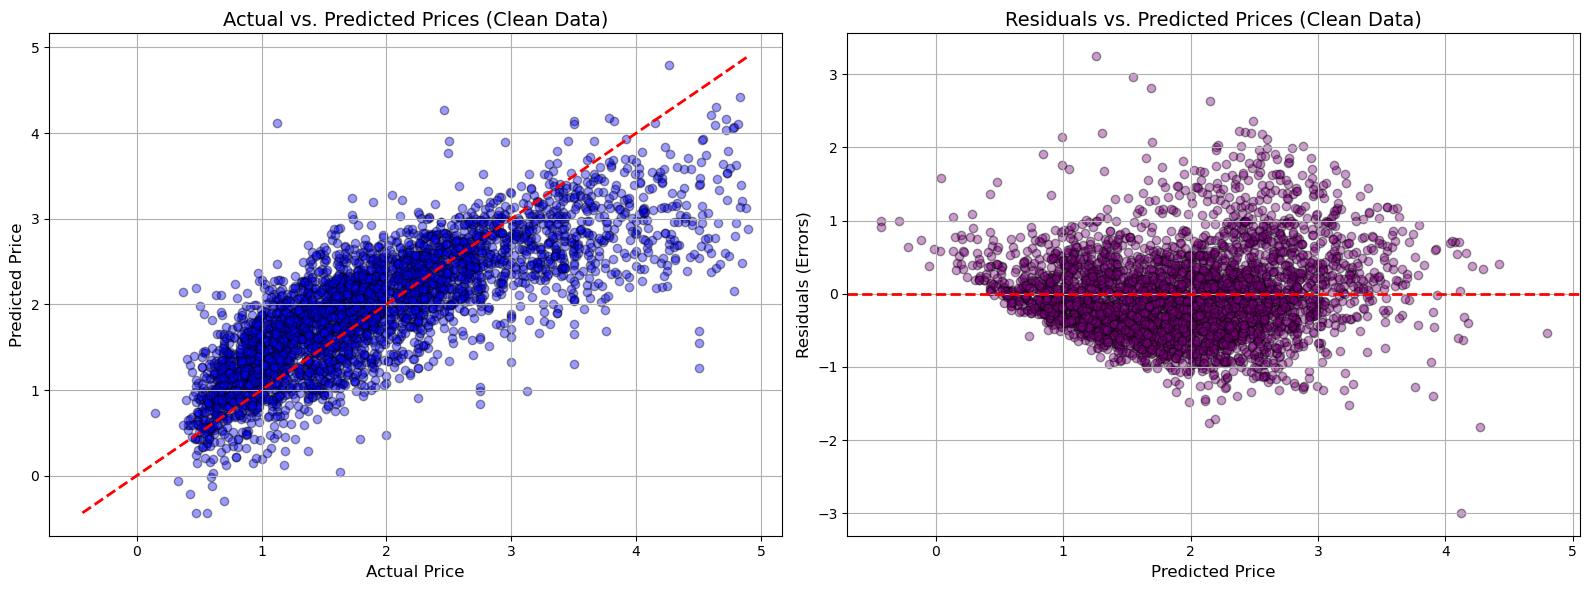

In [47]:
# 1. Generate predictions using your newly trained Lasso model
y_pred = lasso.predict(x_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# PLOT 1: Actual vs Predicted 
ax1.scatter(y_test, y_pred, color="blue", alpha=0.4, edgecolors="k")

min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
ax1.plot([min_val, max_val], [min_val, max_val], color="red", lw=2, linestyle="--")

ax1.set_title("Actual vs. Predicted Prices (Clean Data)", fontsize=14)
ax1.set_xlabel("Actual Price", fontsize=12)
ax1.set_ylabel("Predicted Price", fontsize=12)
ax1.grid(True)


# PLOT 2: Residual Plot
residuals = y_test - y_pred
ax2.scatter(y_pred, residuals, color="purple", alpha=0.4, edgecolors="k")
# Draw zero-error reference line
ax2.axhline(y=0, color="red", lw=2, linestyle="--")

ax2.set_title("Residuals vs. Predicted Prices (Clean Data)", fontsize=14)
ax2.set_xlabel("Predicted Price", fontsize=12)
ax2.set_ylabel("Residuals (Errors)", fontsize=12)
ax2.grid(True)

plt.tight_layout()
plt.show()